# Guía práctica 2

## Ejercicio 2

In [ ]:
from matplotlib.pyplot import (
    figure,
    grid,
    plot,
    show,
    stem,
    title,
    xlabel,
    xticks,
    ylabel,
)
from numpy import (
    arange,
    cos,
    linspace,
    pi,
    sinc,
)
from scipy.signal import freqz

## Señal $x[n]$

En el caso de la señal $x[n]$, tiene componentes en frecuencia tanto en $0Hz$ como en $4Hz$, por lo que una frecuencia de muestreo de $f_s = 6Hz$ viola el teorema del muestreo, ya que $f_s < 2f_{max} = 8Hz$. Por esto es que se espera que la señal muestreada tenga aliasing y no pueda recuperarse la señal original a partir de la señal muestreada. 

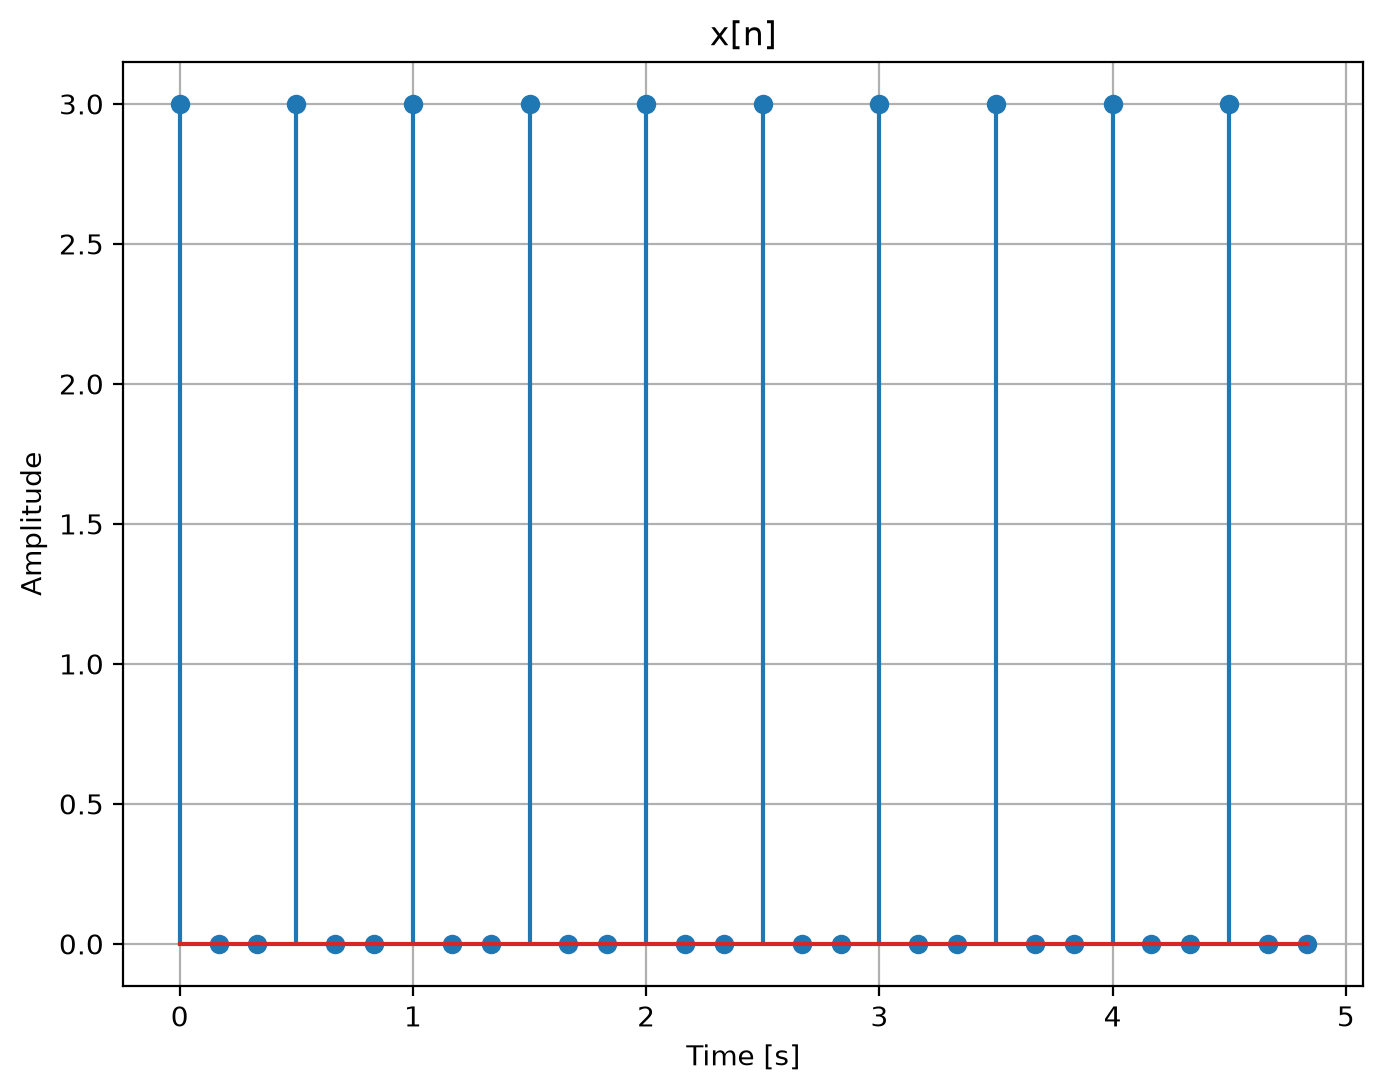

In [24]:
sampling_freq_hz = 6
duration_s = 5
n_samples = int(sampling_freq_hz * duration_s)

t = arange(n_samples) / sampling_freq_hz

x = 1 + 2 * cos(8 * pi * t)

figure(1, figsize=(8, 6), dpi=200)
stem(t, x)
xlabel("Time [s]")
ylabel("Amplitude")
title("x[n]")
grid(True)
show()


La transformada de Fourier de tiempo continuo de la señal $x(t)$ es:

$$
X^F(f) = \delta(f) +  \delta(f - 4) + \delta(f + 4)
$$

El espectro de la señal muestreada $[n]$ será el espectro de la señal original $X^F(f)$ replicado en múltiplos de la frecuencia de muestreo $f_s = 6Hz$. Dado que sólo es posible tratar con señales finitas en el tiempo, se puede suponer que la señal $x[n]$ se multiplica por un cajón de duración *duration_s* segundos, lo que implica que el espectro resultante que se muestra a continuación es el resultado de la convolución de $X^F(f)$ con un sinc, lo que genera un espectro con lóbulos laterales. A mayor duración de la señal, más estrecho será el lóbulo principal del sinc y más pequeños los lóbulos laterales, tendiendo a un espectro más parecido al de la señal original.

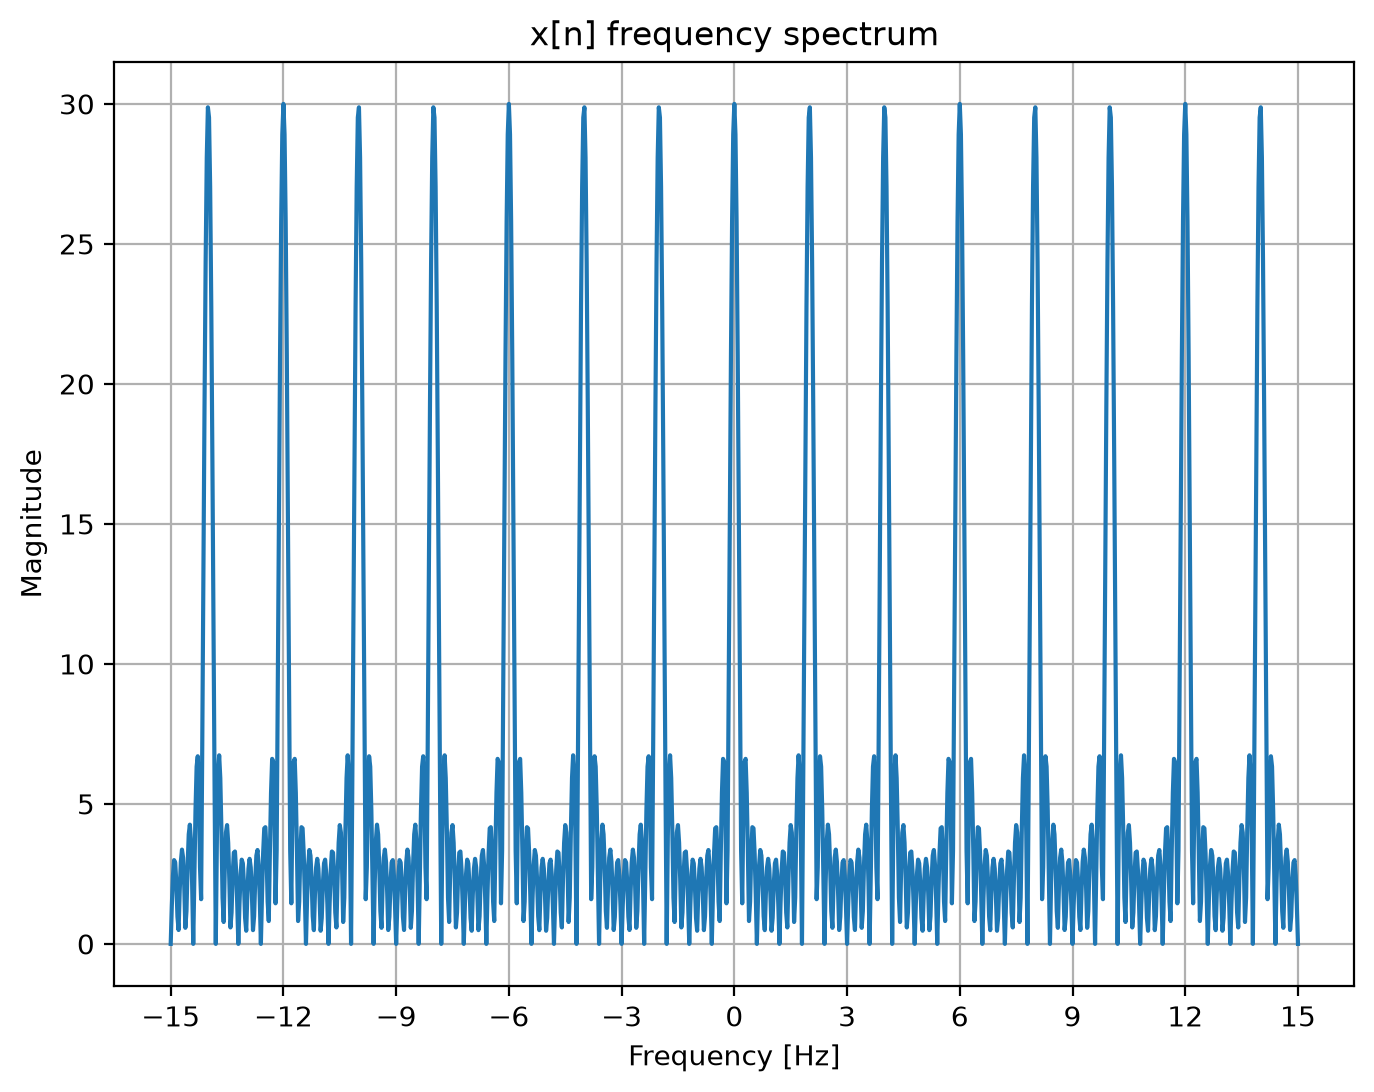

In [ ]:
f_max = 15
f_min = -f_max

f = linspace(f_min, f_max, 1000 + 1)
f, H = freqz(x, worN=f, fs=sampling_freq_hz)

figure(1, figsize=(8, 6), dpi=200)
plot(f, abs(H))
xlabel("Frequency [Hz]")
ylabel("Magnitude")
xticks(arange(f_min, f_max + 1, 3))
title("x[n] frequency spectrum")
grid(True)
show()

Como se puede observar en la figura, el espectro de la señal muestreada tiene aliasing, ya que las réplicas del espectro de la señal original se intercalan. Dentro del ancho de banda de muestreo, que es de $|f|<f_s/2$, se puede observar que la señal muestreada tiene componentes en $0Hz$ y $2Hz$ (este último correspondiente a la réplica en $f_s/2$), por lo que si se tomara esta parte del espectro para reconstruir la señal analógica, se obtendría una señal con la mitad de la frecuencia de la señal original.

## Señal **y[n]**

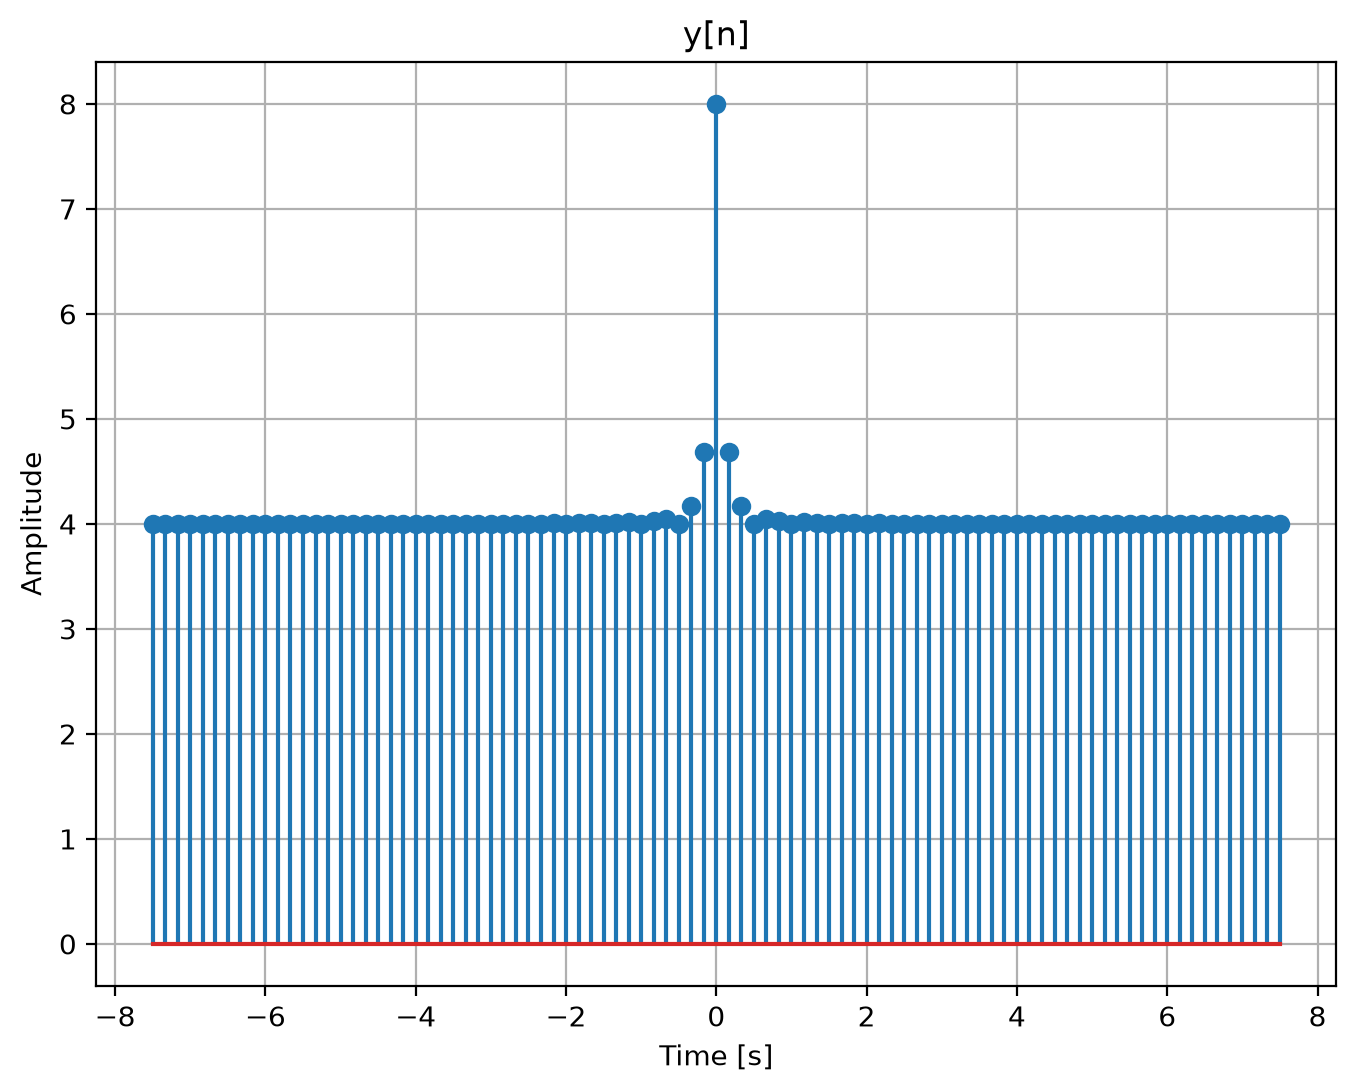

In [33]:
sampling_freq_hz = 6
duration_s = 15
n_samples = int(sampling_freq_hz * duration_s)

t = arange(-n_samples / 2, n_samples / 2 + 1) / sampling_freq_hz

y = 4 + 4 * sinc(4 * t) ** 2

figure(1, figsize=(8, 6), dpi=200)
stem(t, y)
xlabel("Time [s]")
ylabel("Amplitude")
title("y[n]")
grid(True)
show()

La transformada de Fourier de tiempo continuo de la señal $y(t)$ es:

$$
Y^F(f) = 4\delta(f) + \triangle(f/4)
$$

Al igual que en el caso anterior, el espectro resultante que se muestra a continuación es el resultado de la convolución de $Y^F(f)$ con un *sinc*, lo que genera un espectro con lóbulos laterales. El triángulo tiene una base de $-4$ a $4$ Hz. Dado que el espectro se replica cada $f_s = 6Hz$, se puede observar que las réplicas del espectro de la señal original se superponen. Esto implica que la señal original no puede recuperarse. 

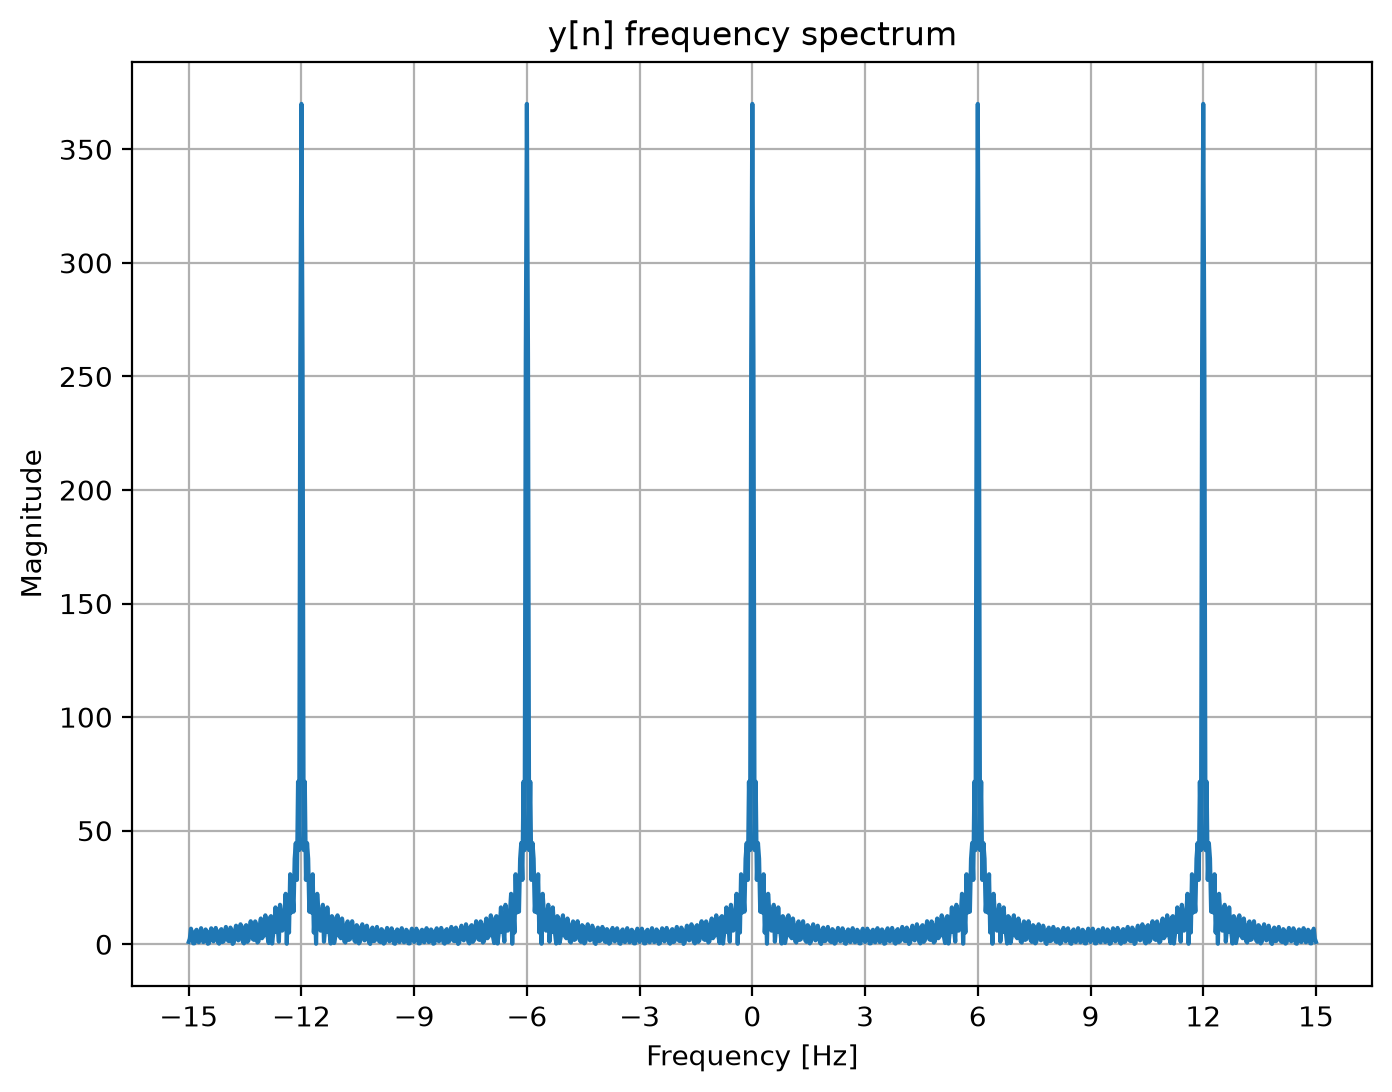

In [34]:
f_max = 15
f_min = -f_max

f = linspace(f_min, f_max, 1000 + 1)
f, H = freqz(y, worN=f, fs=sampling_freq_hz)

figure(1, figsize=(8, 6), dpi=200)
plot(f, abs(H))
xlabel("Frequency [Hz]")
ylabel("Magnitude")
xticks(arange(f_min, f_max + 1, 3))
title("y[n] frequency spectrum")
grid(True)
show()

## Muestreo de $x[n]$ a $f_s = 4Hz$

Al muestrear la señal $x[n]$ con una frecuencia de muestreo de $f_s = 4Hz$, se toman muestras únicamente en los picos del coseno (o, visto de otra forma, se superponen las deltas en frecuencia cero por lo que se suma su amplitud), por lo que la señal muestreada es una señal constante. En este caso es obvio que la señal original no puede recuperarse a partir de la señal muestreada, ya que se pierde gran parte de la información de la señal original. 

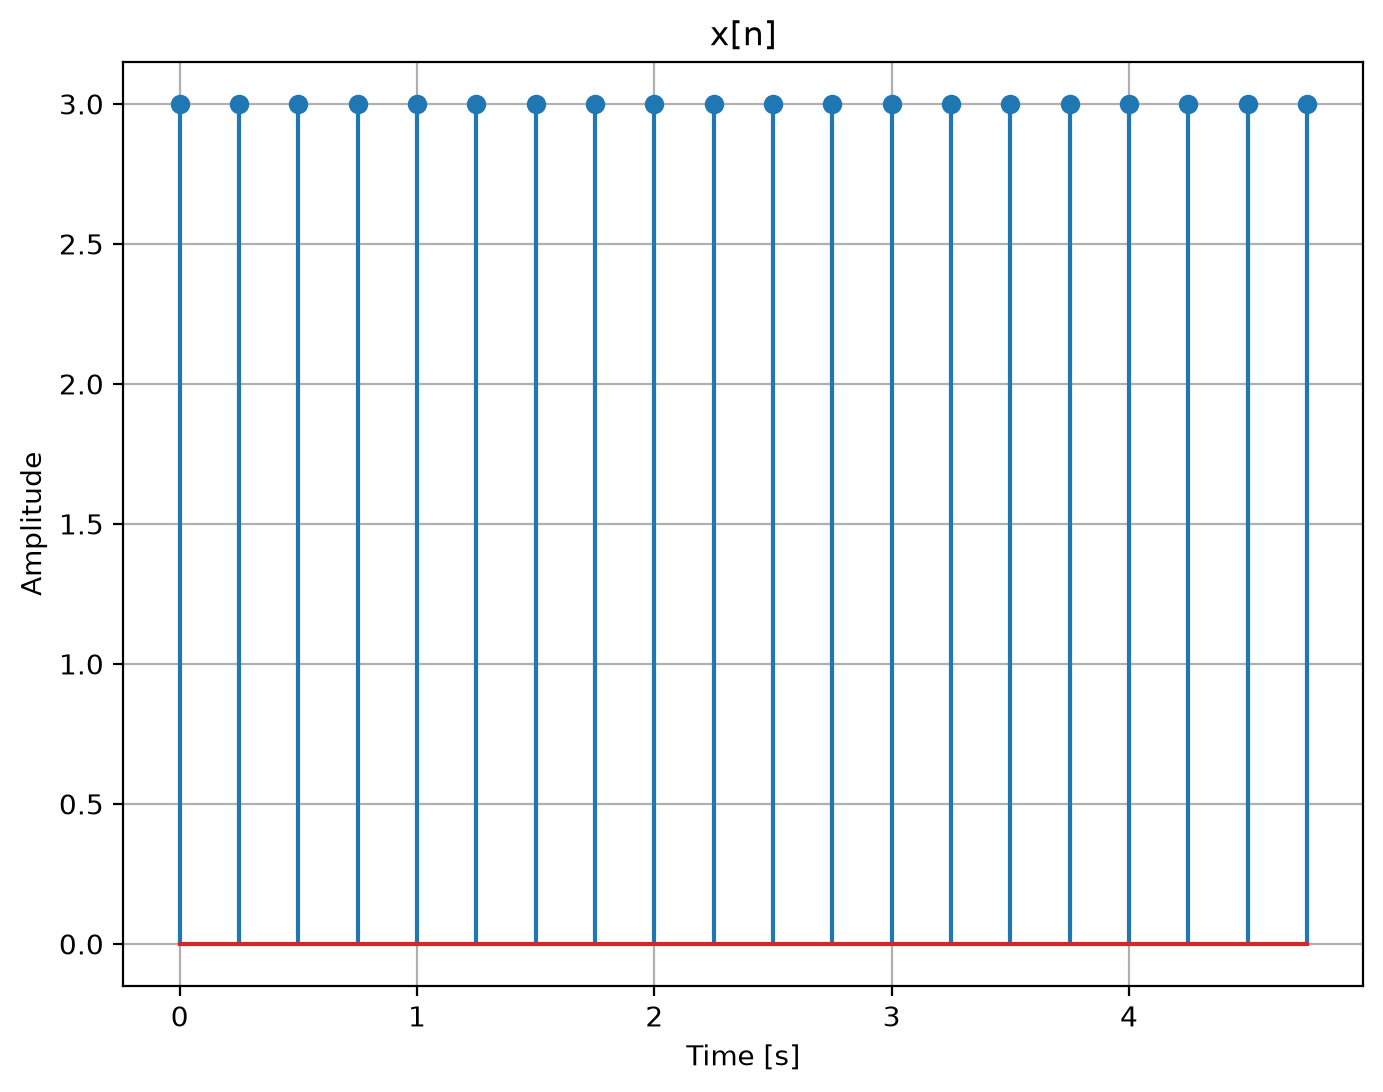

In [35]:
sampling_freq_hz = 4
duration_s = 5
n_samples = int(sampling_freq_hz * duration_s)

t = arange(n_samples) / sampling_freq_hz

x = 1 + 2 * cos(8 * pi * t)

figure(1, figsize=(8, 6), dpi=200)
stem(t, x)
xlabel("Time [s]")
ylabel("Amplitude")
title("x[n]")
grid(True)
show()


Para poder recuperar la señal original a partir de la señal muestreada, es necesario que la frecuencia de muestreo sea de al menos $f_s = 8Hz$. Además, en ese caso podría agregarse un filtro antialiasing con frecuencia de corte de $f_c = f_s/2 = 4Hz$ para eliminar eventuales componentes de frecuencia mayores a $f_c$ y así evitar aliasing en el espectro.